# MelodyMatch-V2 — Final Experimental Results

This notebook consolidates the completed MelodyMatch-V2 experiments.

The experiments cover:

1. Traditional machine-learning baselines
2. CNN-based deep-learning architectures
3. Temporal and Transformer-based architectures
4. Metadata fusion
5. Class-imbalance strategies

The primary evaluation metric is Macro-F1 because the FMA Medium dataset is highly imbalanced.

Additional metrics:

- Accuracy
- Balanced Accuracy
- Weighted-F1

No model training is performed in this notebook.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

In [3]:
final_results = pd.DataFrame(
    [
        ["Logistic Regression", "Traditional", 53.23, 38.78, 35.28, 55.72],
        ["SVM (RBF)", "Traditional", 63.65, 41.61, 43.05, 61.87],
        ["MLP", "Traditional", 58.20, 43.87, 41.49, 59.54],

        ["CNN", "Deep Learning", 60.61, 51.58, 45.27, 62.43],
        ["CNN + BiLSTM", "Deep Learning", 57.50, 45.65, 41.16, 59.19],
        ["CNN + Transformer", "Deep Learning", 48.60, 36.80, 27.67, 48.45],
        ["CNN + Transformer + Metadata", "Deep Learning", 40.98, 32.21, 29.38, 44.92],
        ["CNN + BiLSTM + Attention", "Deep Learning", 58.55, 44.31, 39.32, 59.75],
        ["CNN + Multi-Scale", "Deep Learning", 59.84, 47.99, 41.62, 60.98],

        ["CNN + SpecAugment", "Imbalance / Augmentation", 58.20, 49.50, 42.79, 60.07],
        ["CNN + Mixup", "Imbalance / Augmentation", 60.93, 52.45, 44.40, 62.23],
        ["CNN + Balanced Sampling", "Imbalance", 62.79, 47.95, 44.52, 63.81],
        ["CNN + Decoupled Training", "Imbalance", 62.52, 54.37, 45.65, 64.50],
    ],
    columns=[
        "Model",
        "Category",
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ],
)

final_results

,Model,Category,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
0,Logistic Regression,Traditional,53.23,38.78,35.28,55.72
1,SVM (RBF),Traditional,63.65,41.61,43.05,61.87
2,MLP,Traditional,58.20,43.87,41.49,59.54
3,CNN,Deep Learning,60.61,51.58,45.27,62.43
4,CNN + BiLSTM,Deep Learning,57.50,45.65,41.16,59.19
5,CNN + Transformer,Deep Learning,48.60,36.80,27.67,48.45
6,CNN + Transformer + Metadata,Deep Learning,40.98,32.21,29.38,44.92
7,CNN + BiLSTM + Attention,Deep Learning,58.55,44.31,39.32,59.75
8,CNN + Multi-Scale,Deep Learning,59.84,47.99,41.62,60.98
9,CNN + SpecAugment,Imbalance / Augmentation,58.20,49.50,42.79,60.07


In [5]:
final_results.sort_values(
    "Macro-F1",
    ascending=False,
).round(2)

,Model,Category,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
12,CNN + Decoupled Training,Imbalance,62.52,54.37,45.65,64.50
3,CNN,Deep Learning,60.61,51.58,45.27,62.43
11,CNN + Balanced Sampling,Imbalance,62.79,47.95,44.52,63.81
10,CNN + Mixup,Imbalance / Augmentation,60.93,52.45,44.40,62.23
1,SVM (RBF),Traditional,63.65,41.61,43.05,61.87
9,CNN + SpecAugment,Imbalance / Augmentation,58.20,49.50,42.79,60.07
8,CNN + Multi-Scale,Deep Learning,59.84,47.99,41.62,60.98
2,MLP,Traditional,58.20,43.87,41.49,59.54
4,CNN + BiLSTM,Deep Learning,57.50,45.65,41.16,59.19
7,CNN + BiLSTM + Attention,Deep Learning,58.55,44.31,39.32,59.75


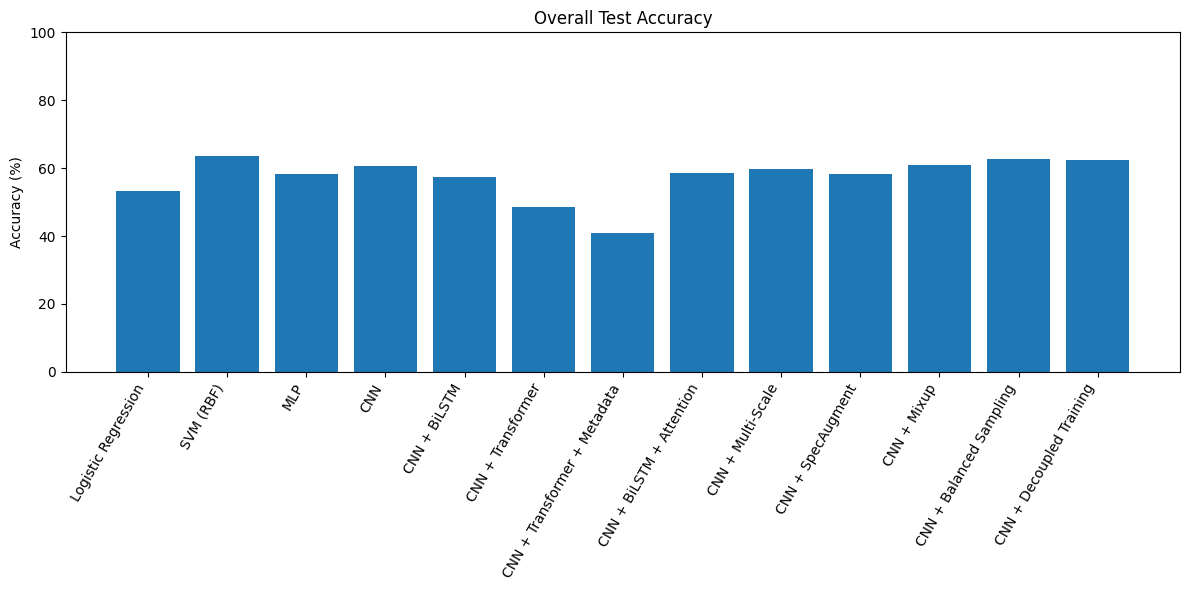

In [6]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"],
)

plt.title("Overall Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

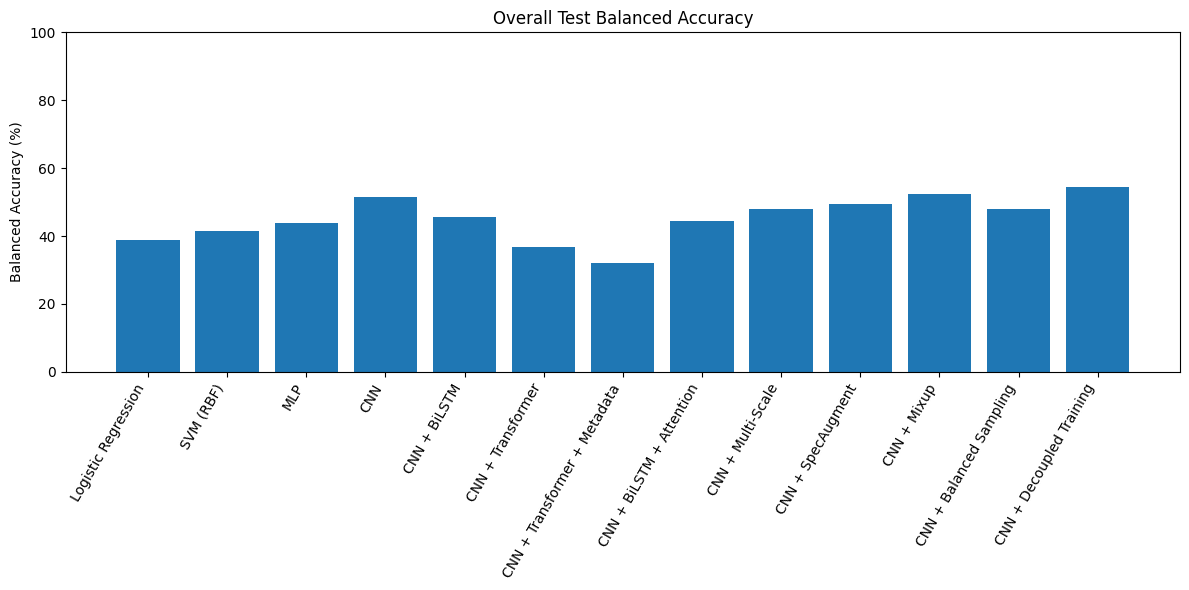

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Balanced Accuracy"],
)

plt.title("Overall Test Balanced Accuracy")
plt.ylabel("Balanced Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

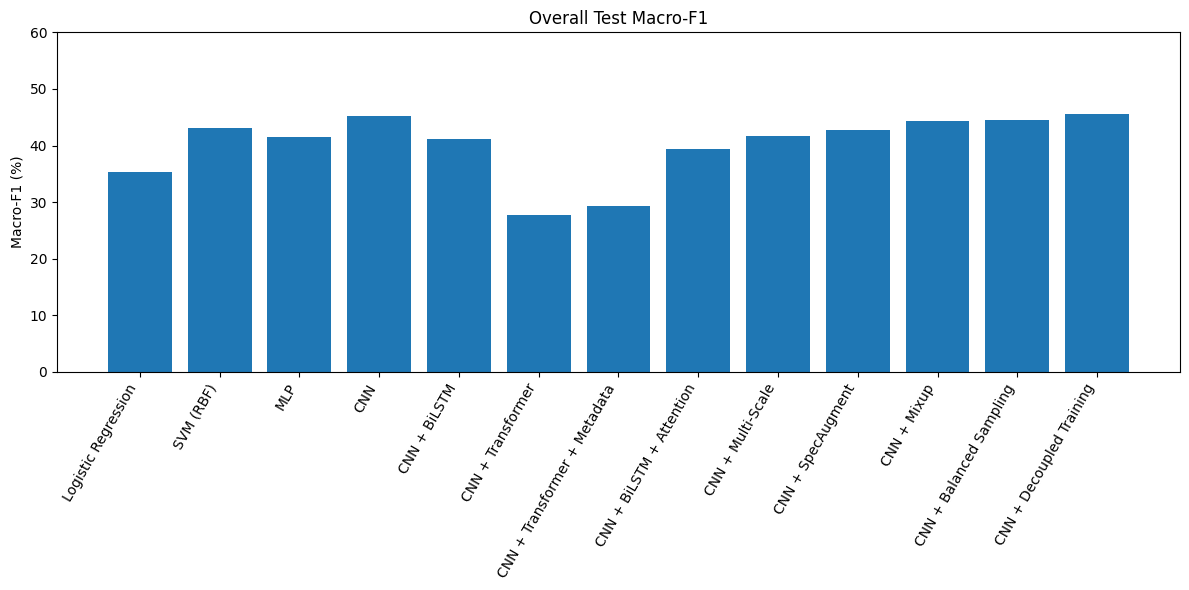

In [8]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Macro-F1"],
)

plt.title("Overall Test Macro-F1")
plt.ylabel("Macro-F1 (%)")
plt.ylim(0, 60)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

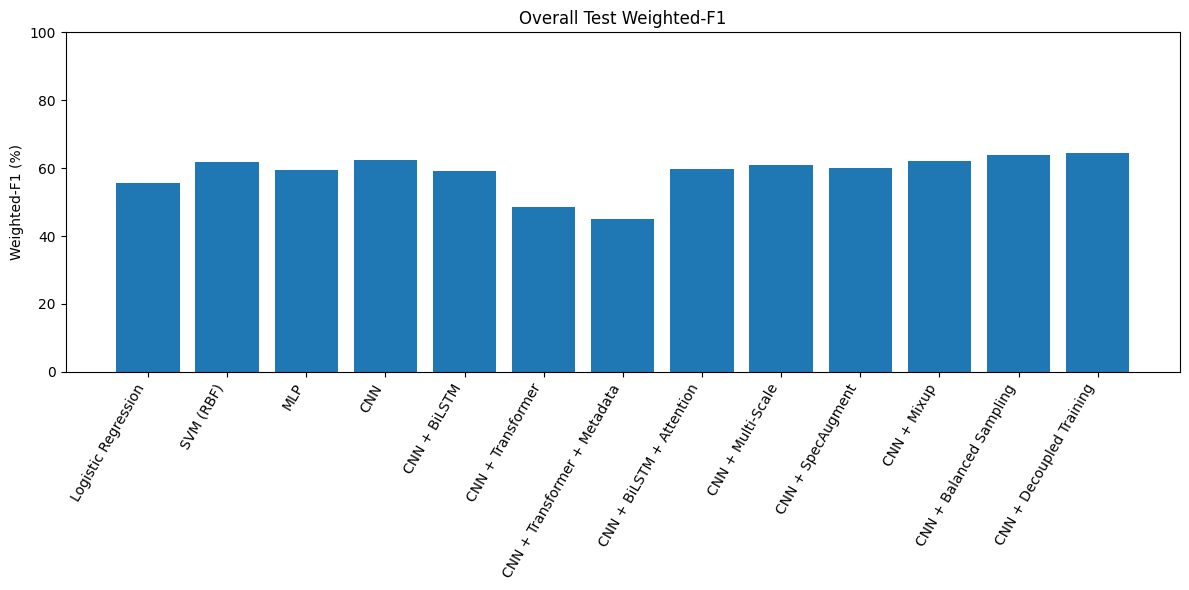

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Weighted-F1"],
)

plt.title("Overall Test Weighted-F1")
plt.ylabel("Weighted-F1 (%)")
plt.ylim(0, 100)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [10]:
deep_models = final_results[
    final_results["Category"] == "Deep Learning"
].copy()

deep_models.round(2)

,Model,Category,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
3,CNN,Deep Learning,60.61,51.58,45.27,62.43
4,CNN + BiLSTM,Deep Learning,57.50,45.65,41.16,59.19
5,CNN + Transformer,Deep Learning,48.60,36.80,27.67,48.45
6,CNN + Transformer + Metadata,Deep Learning,40.98,32.21,29.38,44.92
7,CNN + BiLSTM + Attention,Deep Learning,58.55,44.31,39.32,59.75
8,CNN + Multi-Scale,Deep Learning,59.84,47.99,41.62,60.98


In [11]:
imbalance_models = final_results[
    final_results["Category"].isin(
        ["Imbalance", "Imbalance / Augmentation"]
    )
].copy()

imbalance_models.round(2)

,Model,Category,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
9,CNN + SpecAugment,Imbalance / Augmentation,58.20,49.50,42.79,60.07
10,CNN + Mixup,Imbalance / Augmentation,60.93,52.45,44.40,62.23
11,CNN + Balanced Sampling,Imbalance,62.79,47.95,44.52,63.81
12,CNN + Decoupled Training,Imbalance,62.52,54.37,45.65,64.50


In [12]:
cnn_vs_decoupled = final_results[
    final_results["Model"].isin(
        [
            "CNN",
            "CNN + Decoupled Training",
        ]
    )
].set_index("Model")

cnn_vs_decoupled.round(2)

,Category,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
Model,,,,,
CNN,Deep Learning,60.61,51.58,45.27,62.43
CNN + Decoupled Training,Imbalance,62.52,54.37,45.65,64.50


In [14]:
metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro-F1",
    "Weighted-F1",
]

decoupled_delta = (
    cnn_vs_decoupled.loc[
        "CNN + Decoupled Training",
        metric_columns,
    ]
    - cnn_vs_decoupled.loc[
        "CNN",
        metric_columns,
    ]
)

decoupled_delta.round(2)

Accuracy             1.91
Balanced Accuracy    2.79
Macro-F1             0.38
Weighted-F1          2.07
dtype: object

In [15]:
metric_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ],
    "Highest Test Value": [
        final_results["Accuracy"].max(),
        final_results["Balanced Accuracy"].max(),
        final_results["Macro-F1"].max(),
        final_results["Weighted-F1"].max(),
    ],
})

metric_summary

,Metric,Highest Test Value
0,Accuracy,63.65
1,Balanced Accuracy,54.37
2,Macro-F1,45.65
3,Weighted-F1,64.50


In [16]:
metric_models = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ],
    "Model": [
        final_results.loc[final_results["Accuracy"].idxmax(), "Model"],
        final_results.loc[final_results["Balanced Accuracy"].idxmax(), "Model"],
        final_results.loc[final_results["Macro-F1"].idxmax(), "Model"],
        final_results.loc[final_results["Weighted-F1"].idxmax(), "Model"],
    ],
    "Test Value (%)": [
        final_results["Accuracy"].max(),
        final_results["Balanced Accuracy"].max(),
        final_results["Macro-F1"].max(),
        final_results["Weighted-F1"].max(),
    ],
})

metric_models.round(2)

,Metric,Model,Test Value (%)
0,Accuracy,SVM (RBF),63.65
1,Balanced Accuracy,CNN + Decoupled Training,54.37
2,Macro-F1,CNN + Decoupled Training,45.65
3,Weighted-F1,CNN + Decoupled Training,64.50


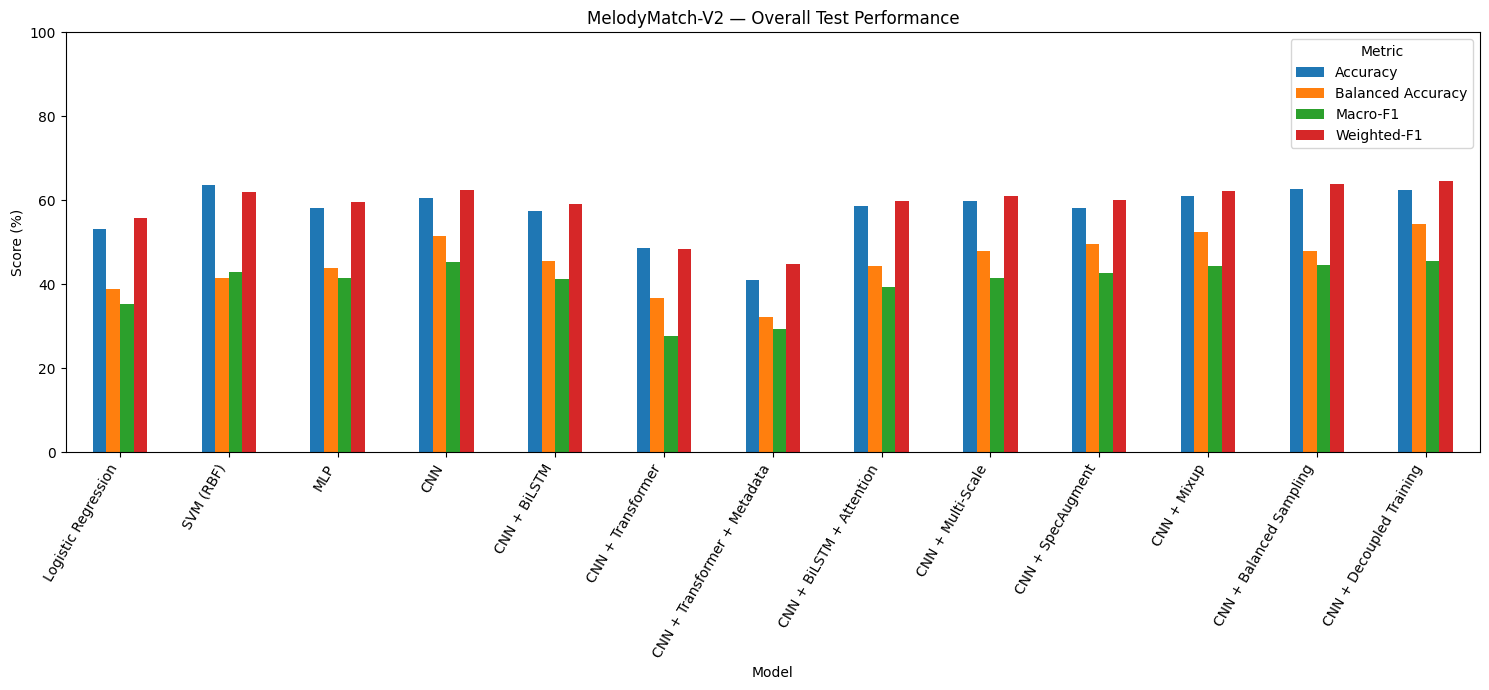

In [17]:
plot_df = final_results.set_index("Model")[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(15, 7),
)

ax.set_title("MelodyMatch-V2 — Overall Test Performance")
ax.set_ylabel("Score (%)")
ax.set_xlabel("Model")
ax.set_ylim(0, 100)

plt.xticks(rotation=60, ha="right")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## Final Findings

### Traditional baselines

The traditional feature-based baselines establish a useful reference point.

The RBF SVM achieves the highest test accuracy among all evaluated models at 63.65%, while its Macro-F1 is 43.05%.

### Deep-learning architectures

The standard CNN achieves 45.27% test Macro-F1.

Adding a BiLSTM, Transformer, attention pooling, metadata fusion, or multi-scale convolution does not improve Macro-F1 over the standard CNN under the evaluated configurations.

The CNN + Transformer model achieves 27.67% Macro-F1, while adding metadata increases this to 29.38%.

### Imbalance experiments

The imbalance experiments produce different trade-offs between accuracy and minority-class-oriented metrics.

Mixup increases balanced accuracy relative to the CNN, while Balanced Sampling increases accuracy and weighted-F1.

The tested Focal Loss and SpecAugment configurations do not improve the CNN baseline.

### Decoupled Training

CNN + Decoupled Training achieves:

- Accuracy: 62.52%
- Balanced Accuracy: 54.37%
- Macro-F1: 45.65%
- Weighted-F1: 64.50%

Relative to the original CNN, this corresponds to:

- +1.91 percentage points Accuracy
- +2.79 percentage points Balanced Accuracy
- +0.38 percentage points Macro-F1
- +2.07 percentage points Weighted-F1

The improvement is therefore not limited to a single evaluation metric.

### Overall research observation

The experiments indicate that increasing model complexity alone does not guarantee improved music genre classification performance.

The standard CNN provides a strong representation-learning baseline, while the decoupled training strategy provides a useful approach for addressing the severe class imbalance in FMA Medium.

In [18]:
final_results.to_csv(
    METRICS_DIR / "final_experiment_comparison.csv",
    index=False,
)

print(
    "Saved: final_experiment_comparison.csv",
)

Saved: final_experiment_comparison.csv


## Conclusion

MelodyMatch-V2 evaluates traditional machine-learning models, CNN-based architectures, temporal models, Transformer variants, metadata fusion, augmentation methods, sampling strategies, and decoupled training.

The experiments demonstrate that performance depends not only on architectural complexity but also on how the severe class imbalance is handled.

The final evaluation uses the frozen test set and reports Accuracy, Balanced Accuracy, Macro-F1, and Weighted-F1 for comparison across experiments.